In [26]:
# =========================
# 0) IMPORTS Y CONFIGURACIÓN
# =========================
# Importamos librerías básicas y Keras/TensorFlow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

# Configuración estética para gráficas
sns.set(font_scale=1.2)
plt.style.use('seaborn-v0_8-darkgrid')

# Fijamos una semilla para reproducibilidad (opcional)
np.random.seed(42)
tf.random.set_seed(42)

print('Librerías cargadas correctamente. TensorFlow version:', tf.__version__)


Librerías cargadas correctamente. TensorFlow version: 2.19.0


In [27]:
# ============================================
# 1) CARGA Y PREPROCESAMIENTO DEL DATASET MNIST
# ============================================
# Cargamos MNIST (imágenes 28x28 de dígitos 0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizamos los pixeles a rango [0,1] y convertimos a float32
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Añadimos el canal de profundidad (1) → shape (N,28,28,1)
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Convertimos etiquetas a one-hot para clasificación con las CNNs
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print('Shapes:')
print('  X_train:', X_train.shape)
print('  X_test :', X_test.shape)
print('  y_train (categorical):', y_train_cat.shape)
print('  y_test (categorical):', y_test_cat.shape)


Shapes:
  X_train: (60000, 28, 28, 1)
  X_test : (10000, 28, 28, 1)
  y_train (categorical): (60000, 10)
  y_test (categorical): (10000, 10)


In [28]:
# ============================================
# 2) DEFINICIÓN DE MODELO CNN
# ============================================

# MODELO CNN Profunda (2 conv + pool, luego otras 2 conv + pool)
inputs2 = Input(shape=(28,28,1), name='input_profundo')
# Bloque 1: 2 convoluciones seguidas y pooling
x2 = Conv2D(32, (3,3), activation='relu', padding='same', name='conv2d_1')(inputs2)
x2 = Conv2D(64, (3,3), activation='relu', padding='same', name='conv2d_2')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_1')(x2)
# Bloque 2: otras 2 convoluciones y pooling
x2 = Conv2D(128, (3,3), activation='relu', padding='same', name='conv2d_3')(x2)
x2 = Conv2D(256, (3,3), activation='relu', padding='same', name='conv2d_4')(x2)
x2 = MaxPooling2D((2,2), name='maxpool_2')(x2)
# Final
x2 = Flatten(name='flatten')(x2)
x2 = Dense(256, activation='relu', name='dense_256')(x2)
outputs2 = Dense(10, activation='softmax', name='output')(x2)

cnn_profundo = Model(inputs2, outputs2, name='CNN_Profundo')
cnn_profundo.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print('\nModelo creado CNN Profundo')



Modelo creado CNN Profundo


In [29]:
# Mostrar resúmenes (arquitectura y parámetros)
print('\n--- Resumen: CNN Profundo ---')
cnn_profundo.summary()


--- Resumen: CNN Profundo ---


Model: "CNN_Profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_profundo (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,601,930 (13.74 MB)

 Trainable params: 3,601,930 (13.74 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# ============================================
# 3) ENTRENAMIENTO
# ============================================
epochs = 50        # Ajusta según recurso (Colab GPU: sube si quieres)
batch_size = 128

# Entrenamos la CNN profunda (mismas condiciones)
history_profundo = cnn_profundo.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.8934 - loss: 0.3370 - val_accuracy: 0.9872 - val_loss: 0.0457
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9883 - loss: 0.0394 - val_accuracy: 0.9890 - val_loss: 0.0428
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9925 - loss: 0.0243 - val_accuracy: 0.9897 - val_loss: 0.0359
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9947 - loss: 0.0173 - val_accuracy: 0.9883 - val_loss: 0.0463
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9960 - loss: 0.0118 - val_accuracy: 0.9898 - val_loss: 0.0401
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9970 - loss: 0.0097 - val_accuracy: 0.9912 - val_loss: 0.0488
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9969 - loss: 0.0096 - val_accuracy: 0.9878 - val_loss: 0.0529
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9975 - loss: 0.0072 - val_acc

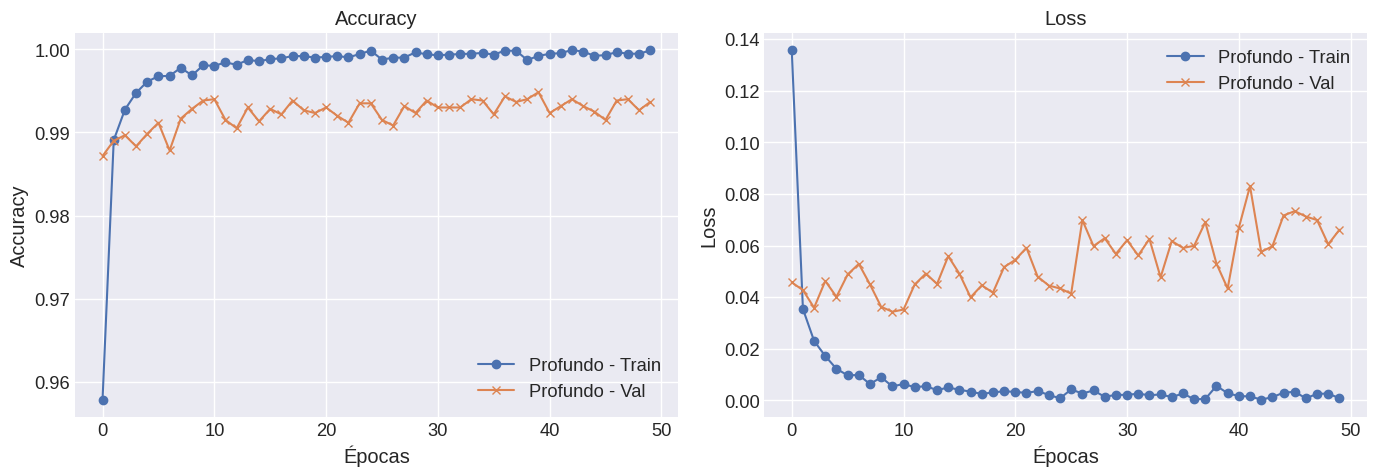

In [31]:
# ============================================
# 4) COMPARACIÓN VISUAL: Accuracy y Loss
# ============================================
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_profundo.history['accuracy'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_accuracy'], marker='x', label='Profundo - Val')
plt.title('Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_profundo.history['loss'], marker='o', label='Profundo - Train')
plt.plot(history_profundo.history['val_loss'], marker='x', label='Profundo - Val')
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



=== CNN Profundo: 4 capas convolucionales detectadas ===

Procesando capa: conv2d_1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


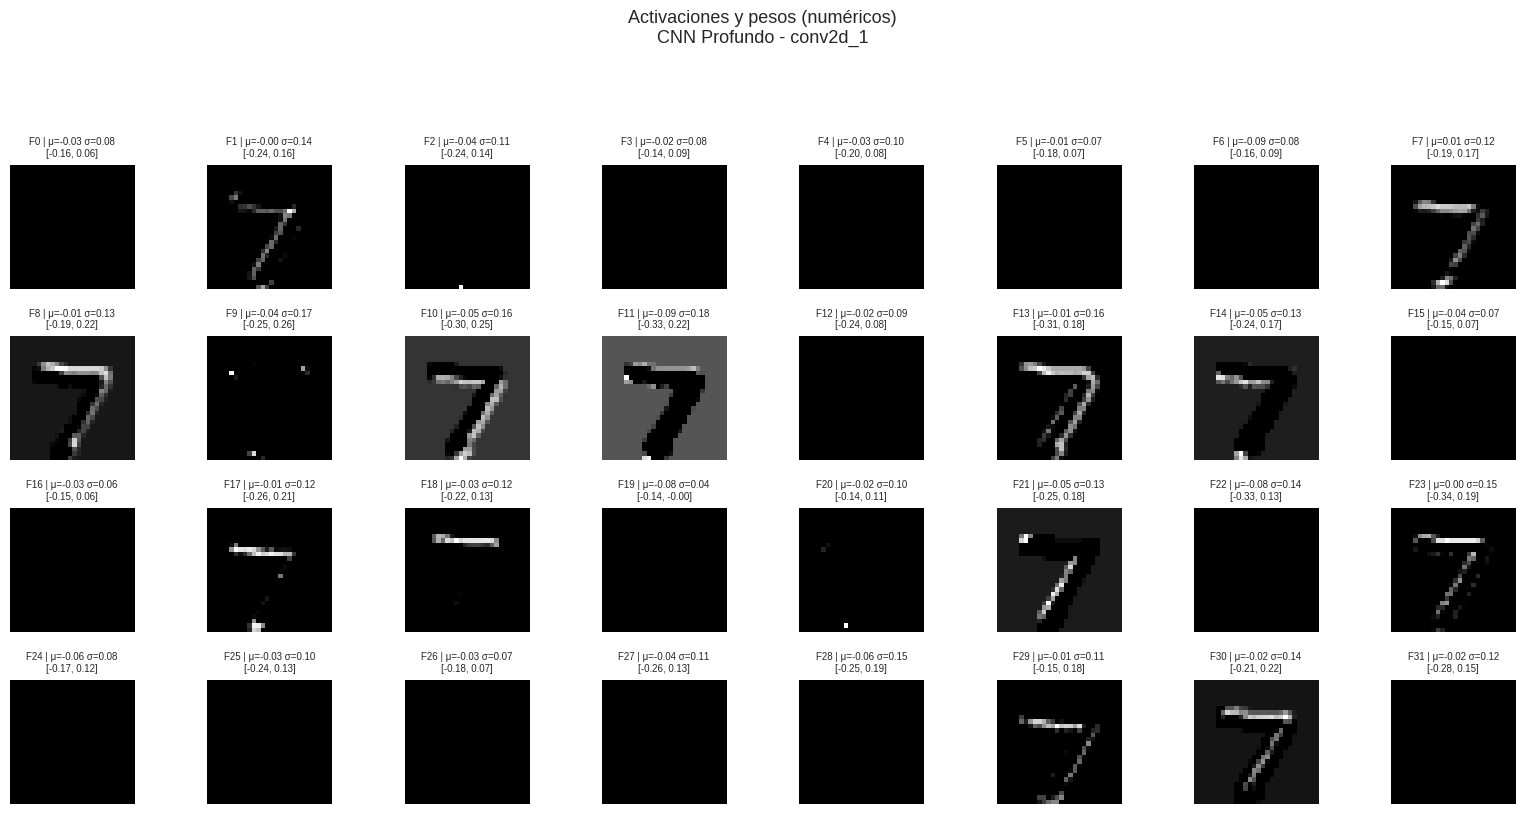

Procesando capa: conv2d_2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


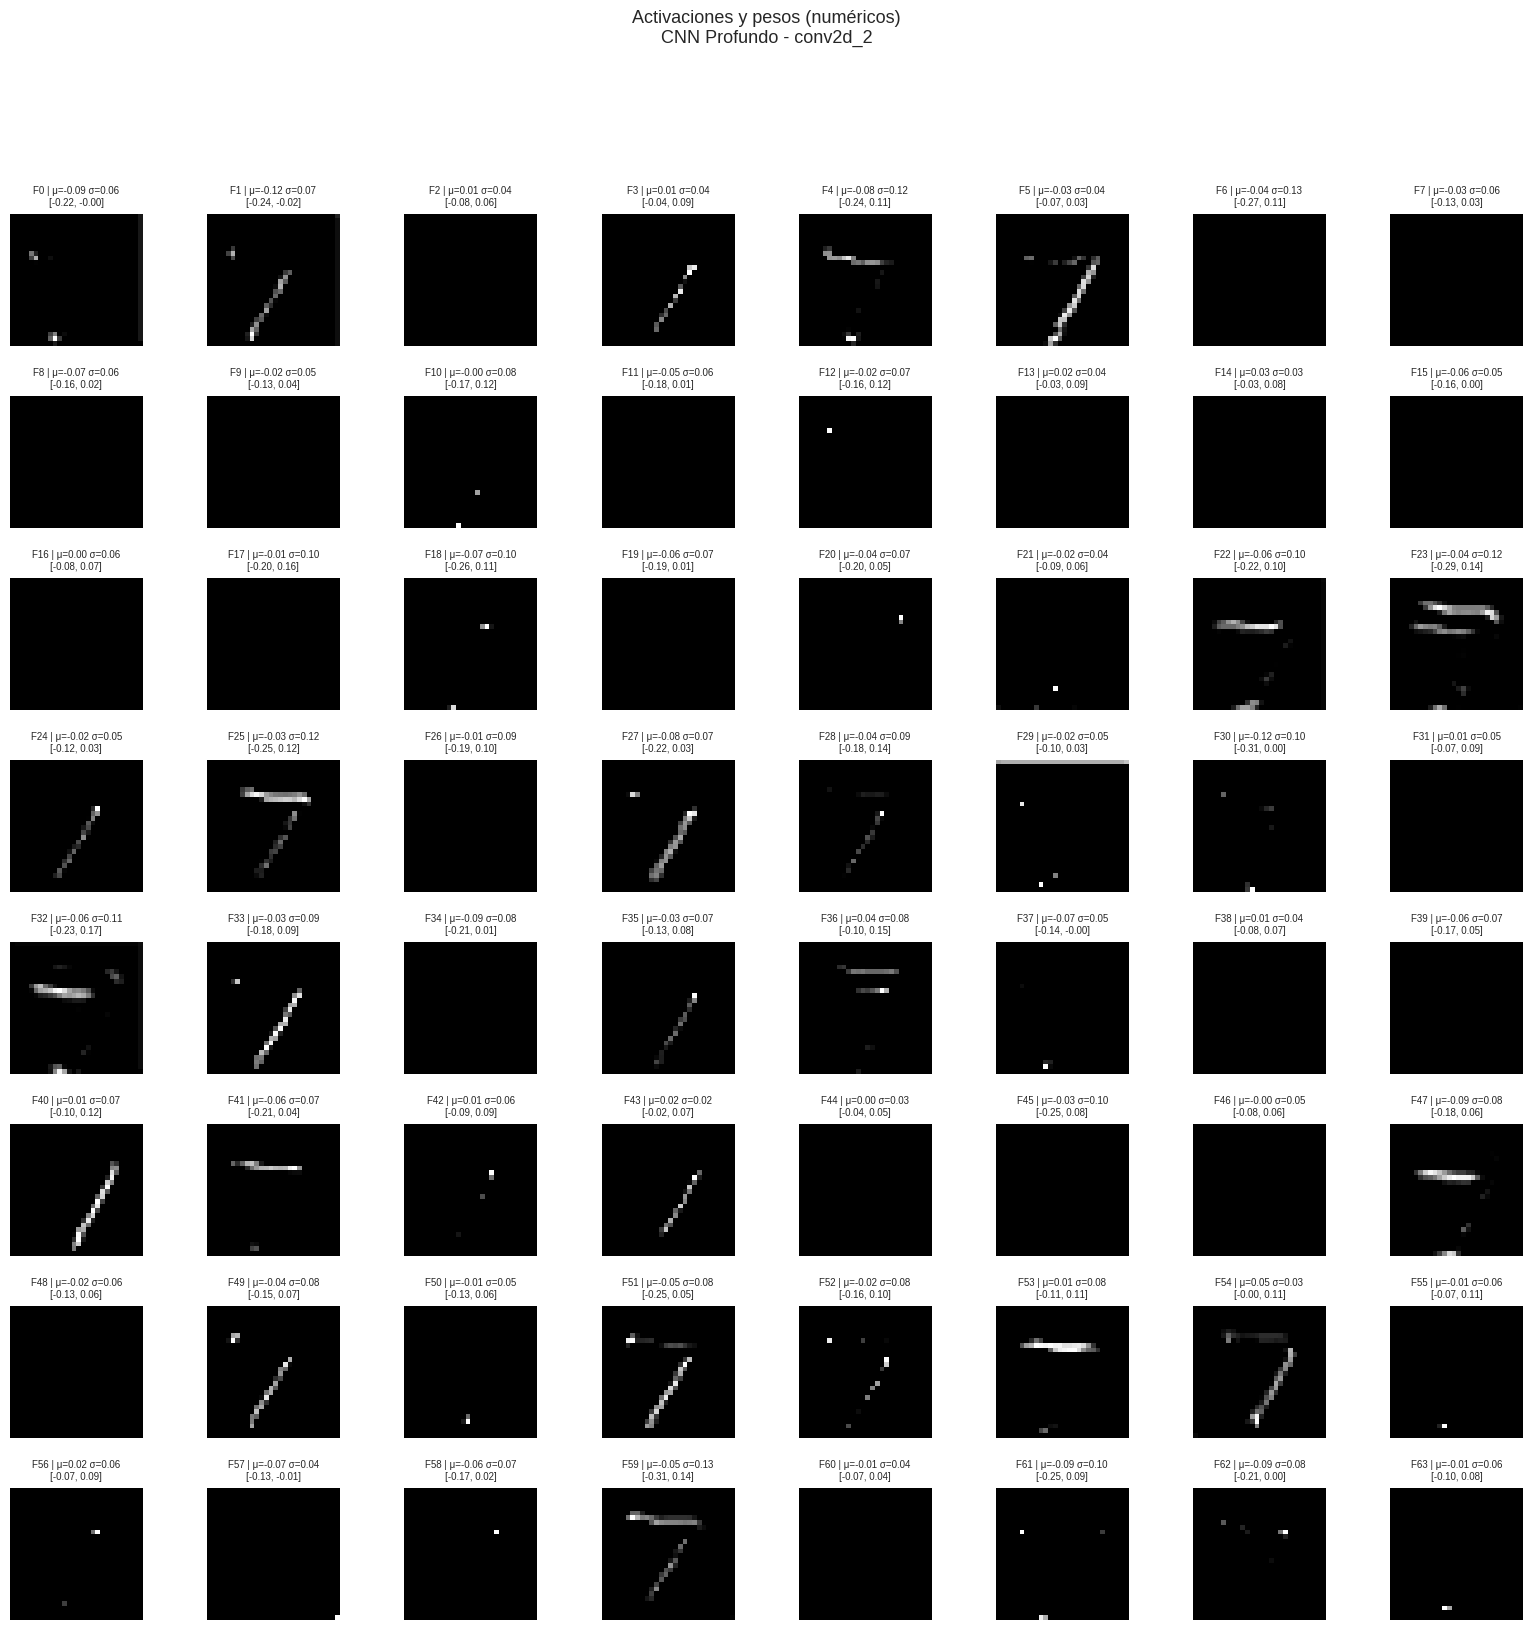

Procesando capa: conv2d_3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


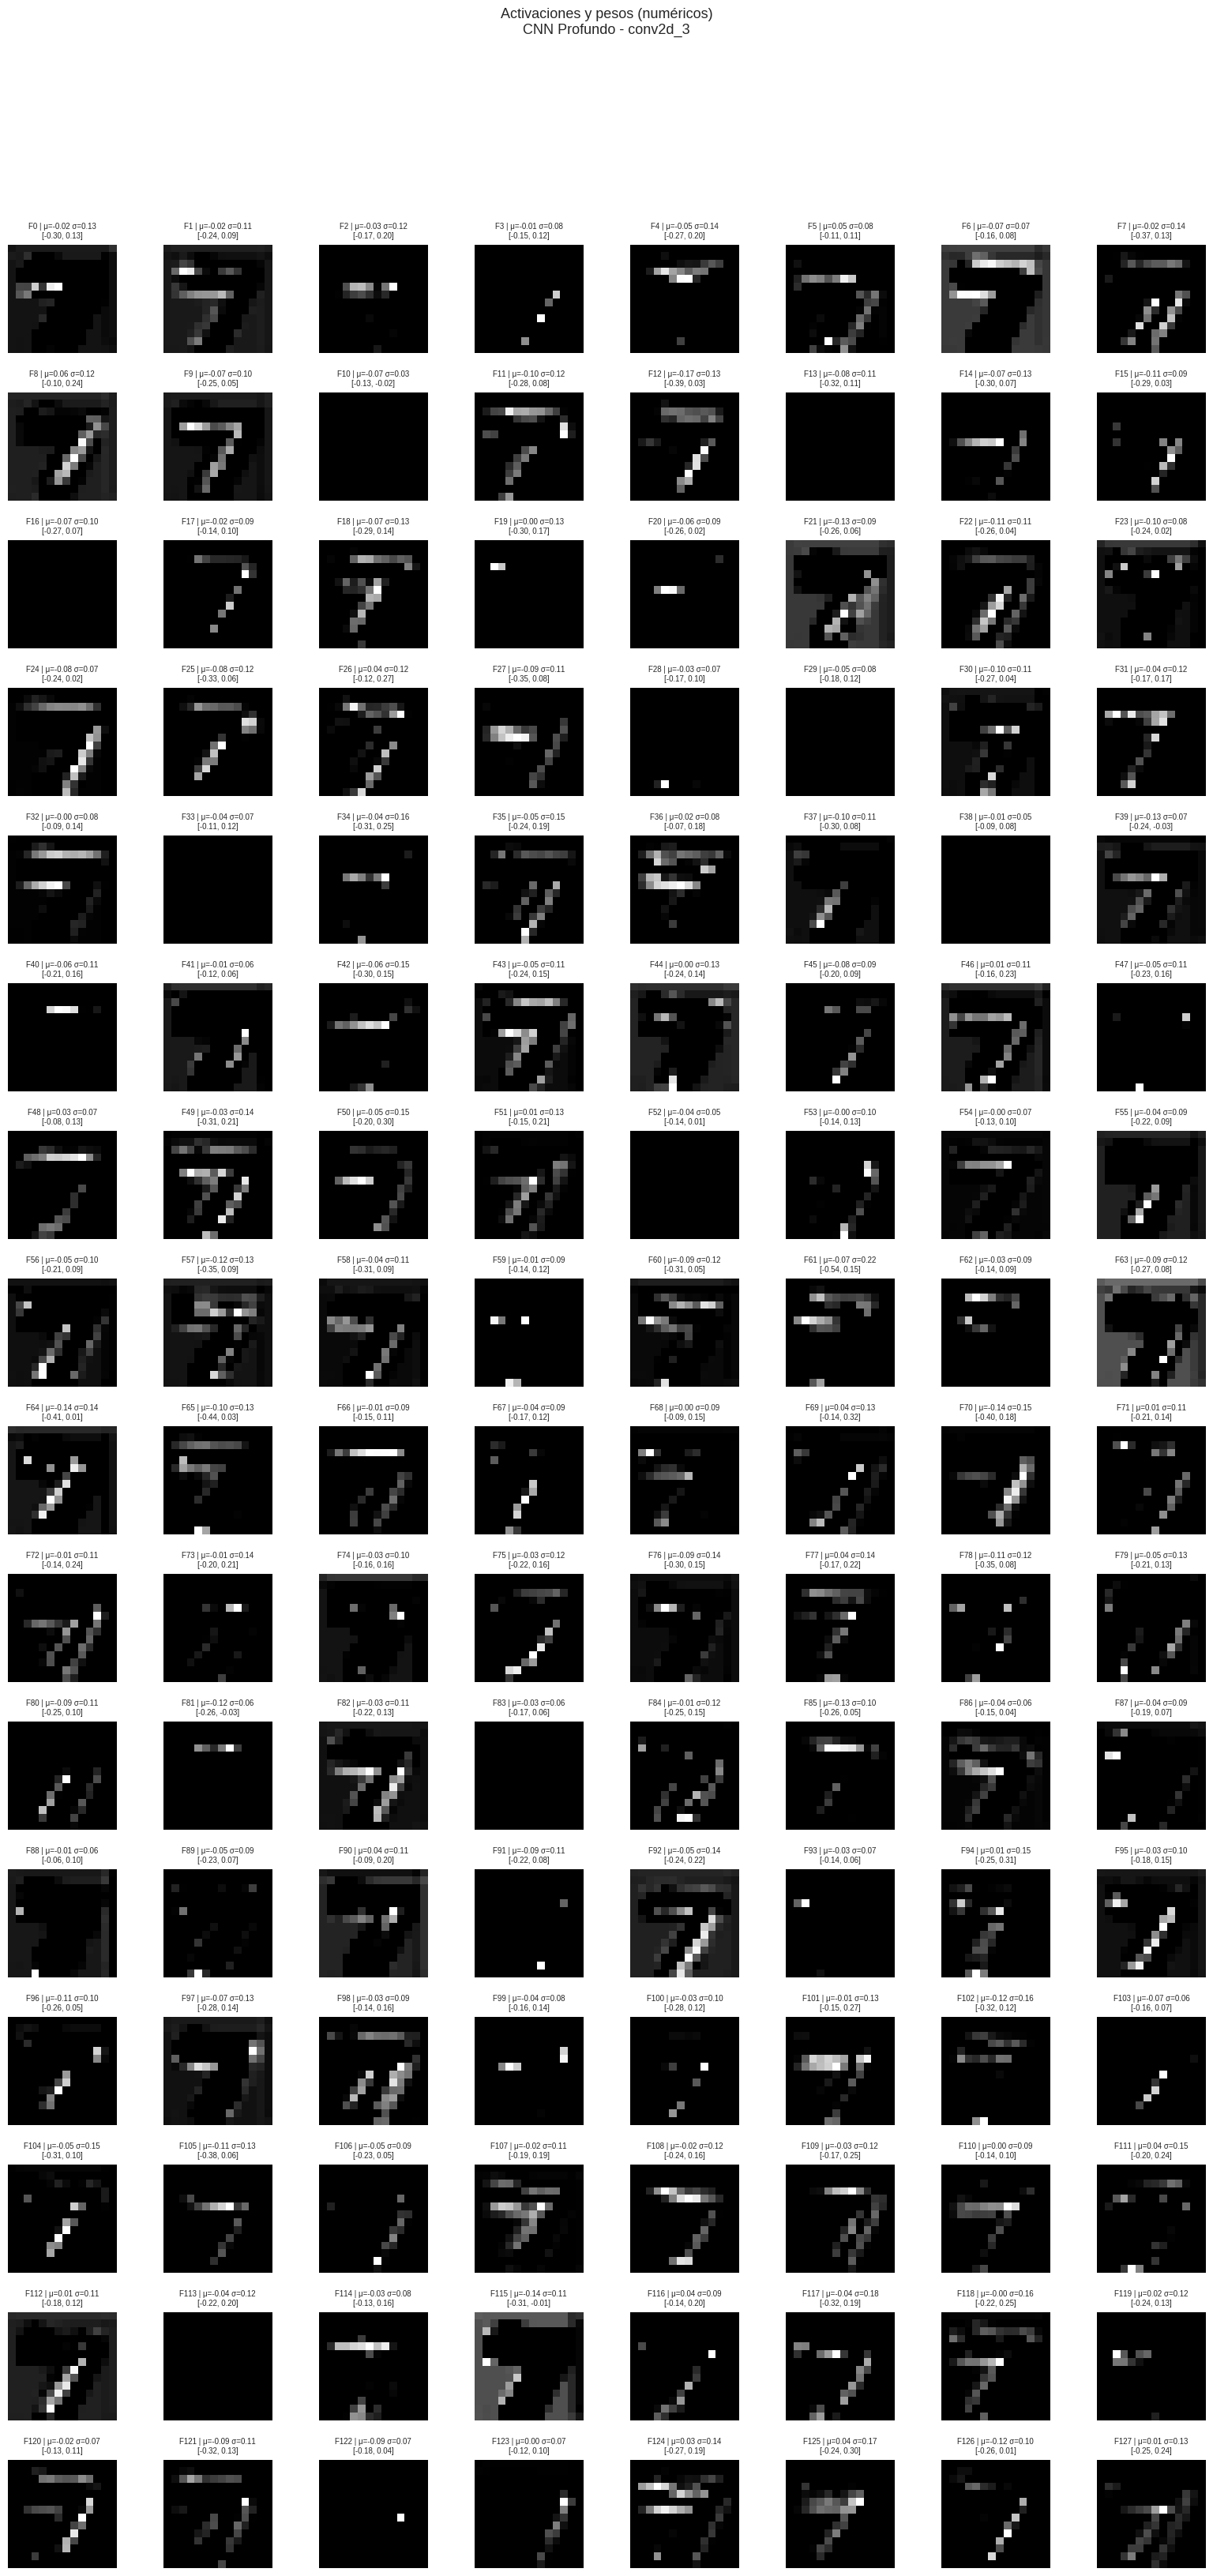

Procesando capa: conv2d_4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


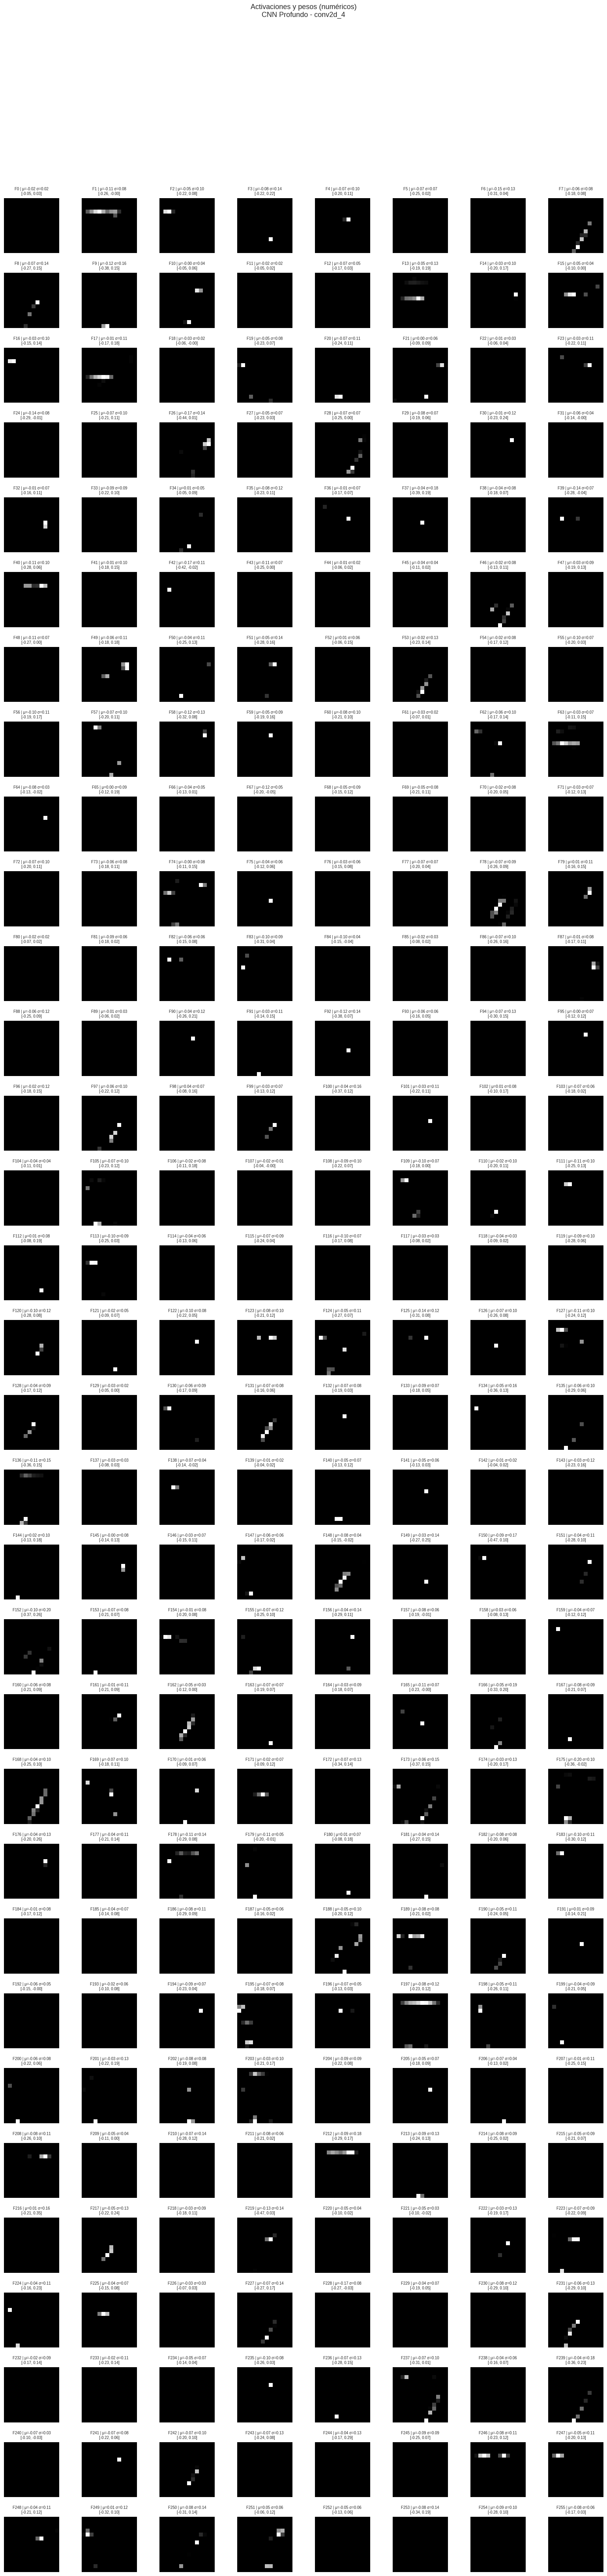

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.datasets import mnist
import numpy as np

# Cargar datos MNIST
(_, _), (x_test, _) = mnist.load_data()

# Seleccionar una imagen de prueba y darle forma correcta
base_img = x_test[0].astype('float32') / 255.0
base_img = np.expand_dims(base_img, axis=-1)  # Añadir canal (28,28,1)


def plot_conv_filters(model, img, layer_name, model_name="CNN"):

    if img.ndim == 3:
        img = img[np.newaxis, ...]

    layer = model.get_layer(layer_name)
    weights, biases = layer.get_weights()
    act_model = Model(inputs=model.input, outputs=layer.output)
    activations = act_model.predict(img)[0]

    n_filters = activations.shape[-1]
    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))

    plt.figure(figsize=(n_cols*2, n_rows*2))
    for i in range(n_filters):
        kernel = weights[:, :, 0, i]
        mean_w = np.mean(kernel)
        std_w = np.std(kernel)
        min_w = np.min(kernel)
        max_w = np.max(kernel)

        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(activations[:, :, i], cmap='gray')
        plt.axis('off')
        plt.title(f"F{i} | μ={mean_w:.2f} σ={std_w:.2f}\n[{min_w:.2f}, {max_w:.2f}]", fontsize=7)

    # --- Ajuste del espaciado del título ---
    plt.suptitle(f"Activaciones y pesos (numéricos)\n{model_name} - {layer_name}", fontsize=13, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_all_conv_layers(model, img, model_name="CNN"):
    """
    Muestra las activaciones y pesos numéricos de todas las capas Conv2D de un modelo.
    """
    conv_layers = [layer.name for layer in model.layers if isinstance(layer, Conv2D)]

    if not conv_layers:
        print(f"{model_name}: No se encontraron capas convolucionales.")
        return

    print(f"\n=== {model_name}: {len(conv_layers)} capas convolucionales detectadas ===\n")
    for lname in conv_layers:
        print(f"Procesando capa: {lname}")
        plot_conv_filters(model, img, lname, model_name)


# --- Uso ---
plot_all_conv_layers(cnn_profundo, base_img, "CNN Profundo")


In [33]:
import numpy as np

# Aseguramos batch y tipo float
if base_img.ndim == 2:  # si es (28,28)
    base_img = np.expand_dims(base_img, axis=-1)  # (28,28,1)

base_img = base_img.astype('float32') / 255.0
base_img = np.expand_dims(base_img, axis=0)  # (1,28,28,1)


In [ ]:
def plot_activation_summary(model, img, layer_name, model_name="CNN"):
    from tensorflow.keras.models import Model
    import matplotlib.pyplot as plt
    import numpy as np

    # Aseguramos batch
    if img.ndim == 3:
        img = np.expand_dims(img, axis=0)  # (1,H,W,C)

    # Modelo intermedio para activaciones
    conv_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    activations = conv_model.predict(img)  # shape: (1,H,W,C)

    # Promedio absoluto de activaciones por filtro
    avg_activations = np.mean(np.abs(activations), axis=(1,2))  # (1,C)
    avg_activations = avg_activations.flatten()

    # Gráfica
    plt.figure(figsize=(12,4))
    plt.bar(range(1, len(avg_activations)+1), avg_activations, color='skyblue')
    plt.xlabel("Filtro")
    plt.ylabel("Magnitud promedio de activación")
    plt.title(f"Resumen de activaciones - {model_name} ({layer_name})")
    plt.show()


In [35]:
import tensorflow as tf

def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradientes de la clase objetivo respecto a la salida convolucional
    grads = tape.gradient(class_channel, conv_outputs)

    # Promediar los gradientes sobre ancho y alto
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    # Ponderar mapas de activación
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizar entre 0 y 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [36]:
last_conv_layer_name = "conv2d_4"
heatmap = make_gradcam_heatmap(base_img, cnn_profundo, last_conv_layer_name)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_profundo']]
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)


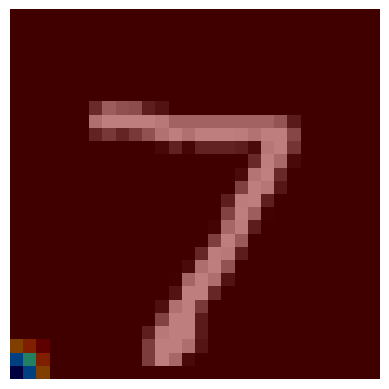

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Asegurarse que base_img tiene forma (28,28)
img_gray = np.squeeze(base_img)

# Normalizar la imagen a 0-255
img_gray = img_gray - img_gray.min()
img_gray = img_gray / img_gray.max() * 255
img_gray = img_gray.astype(np.uint8)

# Convertir a RGB
img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

# Redimensionar heatmap a 28x28 y convertir a 0-255
heatmap_resized = cv2.resize(heatmap, (28,28))
heatmap_resized = np.uint8(255 * heatmap_resized)

# Aplicar color al heatmap
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Mezclar imagen y heatmap
superimposed_img = cv2.addWeighted(heatmap_color, 0.5, img_rgb, 0.5, 0)

# Mostrar
plt.imshow(superimposed_img)
plt.axis('off')
plt.show()

